# Fuzzy Cognitive Map – Happiness Dynamics

**Author:** Allizha Theiventhiram  
**Course:** Fuzzy Sets and Systems II  
**Date:** 29.03.2026  

---

## Introduction

This notebook applies **Fuzzy Cognitive Maps (FCM)** to model the dynamics of happiness as a complex system of interacting factors.

Fuzzy Cognitive Maps are particularly suitable for modeling systems characterized by:
- uncertainty,
- vagueness,
- and interdependent relationships between concepts.

Following the methodology presented in the course, the system is defined through:
- an **activation vector** (initial state),
- a **weight matrix** (causal relationships),
- and an **iterative inference process**.

The objective is to:
- simulate system behavior,
- analyze structural importance,
- compare different scenarios,
- and evaluate interventions.

The output concept of interest is **Happiness**, which emerges from the interaction of all other concepts.

#### 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from fcmpy import FcmSimulator, FcmIntervention

#### 2. Define Concepts

The system is composed of five concepts:

- **Stress**: psychological pressure affecting the individual  
- **Sleep**: quality of rest and recovery  
- **Social_Life**: level of social interaction  
- **Productivity**: efficiency in daily activities  
- **Happiness**: overall well-being (output concept)

Happiness is considered the **target concept**, whose value is determined by the interactions of the other variables.

In [2]:
concepts = ["Stress", "Sleep", "Social_Life", "Productivity", "Happiness"]

#### 3. Define weight Matrix

In [3]:
matrix = [
    [0.0, -0.6, -0.4, -0.5, -0.7],
    [-0.5, 0.0, 0.3, 0.4, 0.6],
    [-0.4, 0.2, 0.0, 0.3, 0.7],
    [-0.3, 0.2, 0.2, 0.0, 0.5],
    [0.0, 0.0, 0.0, 0.0, 0.0]
]

df = pd.DataFrame(matrix, columns=concepts, index=concepts)

display(df)

,Stress,Sleep,Social_Life,Productivity,Happiness
Stress,0.0,-0.6,-0.4,-0.5,-0.7
Sleep,-0.5,0.0,0.3,0.4,0.6
Social_Life,-0.4,0.2,0.0,0.3,0.7
Productivity,-0.3,0.2,0.2,0.0,0.5
Happiness,0.0,0.0,0.0,0.0,0.0


#### Interpretation of the Weight Matrix

Each value represents a causal relationship between two concepts:

- Positive values indicate a **supporting influence**
- Negative values indicate an **inhibiting influence**

i.e.
- Stress negatively affects Happiness
- Sleep positively contributes to Happiness
- Social_Life strongly supports Happiness

This matrix defines the structure of the system.

#### 4. Initial State

In [4]:
initial_state = {
    "Stress": 0.6,
    "Sleep": 0.5,
    "Social_Life": 0.4,
    "Productivity": 0.5,
    "Happiness": 0.0
}

#### Initial Activation Vector

The activation vector represents the initial state of the system.

Each concept is assigned a value between 0 and 1.

This corresponds to a **baseline scenario**, from which the system will evolve through iterative updates.

#### 5. Structural Importance

In [5]:
out_degree = df.abs().sum(axis=1)
in_degree = df.abs().sum(axis=0)
centrality = out_degree + in_degree

importance = pd.DataFrame({
    "Out-degree": out_degree,
    "In-degree": in_degree,
    "Centrality": centrality
}).sort_values(by="Centrality", ascending=False)

display(importance)

,Out-degree,In-degree,Centrality
Stress,2.2,1.2,3.4
Sleep,1.8,1.0,2.8
Social_Life,1.6,0.9,2.5
Happiness,0.0,2.5,2.5
Productivity,1.2,1.2,2.4


#### Structural Importance Analysis

This analysis evaluates how important each concept is in the system:

- **Out-degree**: how much a concept influences others  
- **In-degree**: how much a concept is influenced  
- **Centrality**: overall importance  

In this system, Stress appears as the most central concept, indicating that it plays a dominant role in shaping the dynamics of the system.

#### 6. Baseline Simulation

In [6]:
# create simulator
sim = FcmSimulator()

res_sigmoid = sim.simulate(
    initial_state=initial_state,
    weight_matrix=df,
    transfer="sigmoid",
    inference="mKosko",
    thresh=0.001,
    iterations=50,
    l=1
)

display(res_sigmoid)

The values converged in the 9 state (e <= 0.001)


,Stress,Sleep,Social_Life,Productivity,Happiness
0,0.600000,0.500000,0.400000,0.500000,0.000000
1,0.509999,0.579324,0.601088,0.627148,0.601088
2,0.448127,0.626907,0.667370,0.686586,0.790181
3,0.416234,0.652222,0.692857,0.713715,0.840652
4,0.401040,0.664585,0.703657,0.725984,0.856003
5,0.394004,0.670377,0.708439,0.731529,0.861711
6,0.390784,0.673040,0.710591,0.734038,0.864104
7,0.389317,0.674255,0.711565,0.735175,0.865158
8,0.388650,0.674808,0.712007,0.735690,0.865631


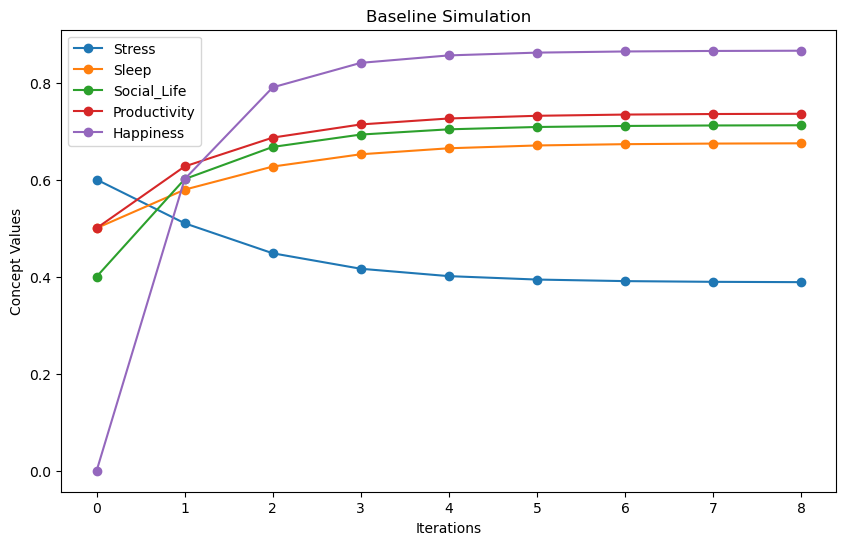

In [7]:
plt.figure(figsize=(10, 6))
res_sigmoid.plot(ax=plt.gca(), marker='o')
plt.title("Baseline Simulation")
plt.xlabel("Iterations")
plt.ylabel("Concept Values")
plt.show()

#### Simulation Process

The system evolves through iterative fuzzy inference until convergence is reached.

At each iteration:
1. causal effects are propagated through the weight matrix
2. values are transformed using a sigmoid function
3. the system updates until convergence

The final state represents an **equilibrium**.

#### 7. Sigmoid vs Tanh

The values converged in the 9 state (e <= 0.001)


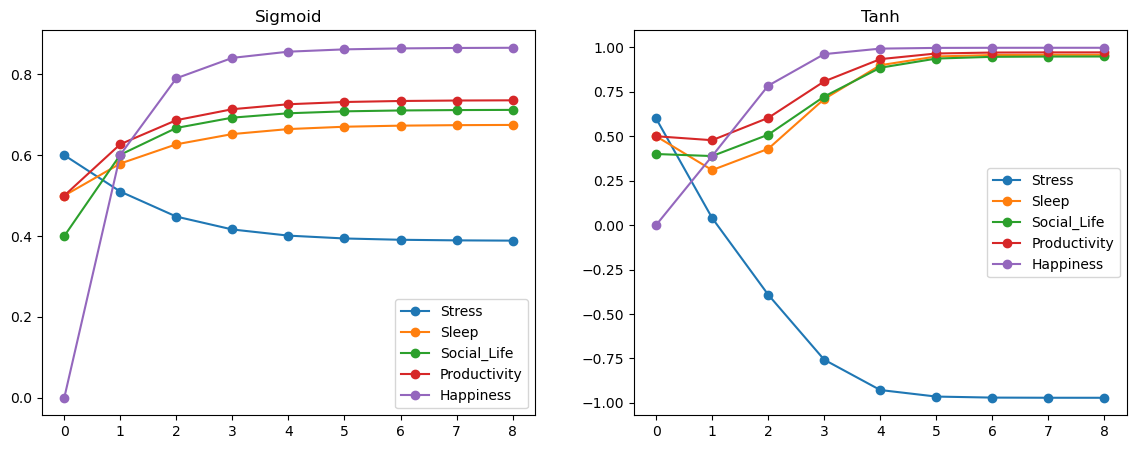

In [8]:
res_tanh = sim.simulate(
    initial_state=initial_state,
    weight_matrix=df,
    transfer="tanh",
    inference="mKosko",
    thresh=0.001,
    iterations=50
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

res_sigmoid.plot(ax=axes[0], marker='o')
axes[0].set_title("Sigmoid")

res_tanh.plot(ax=axes[1], marker='o')
axes[1].set_title("Tanh")

plt.show()

#### Comparison of Transfer Functions

Two transfer functions are used:

- **Sigmoid** → leads to stable convergence  
- **Tanh** → allows more dynamic behavior  

This highlights the importance of non-linearity in fuzzy systems.

#### 8. Scenario Analysis

In [9]:
# High Stress
state_stress = initial_state.copy()
state_stress["Stress"] = 1.0

res_stress = sim.simulate(
    initial_state=state_stress,
    weight_matrix=df,
    transfer="sigmoid",
    inference="mKosko",
    thresh=0.001,
    iterations=50,
    l=1
)

# Better Sleep
state_sleep = initial_state.copy()
state_sleep["Sleep"] = 1.0

res_sleep = sim.simulate(
    initial_state=state_sleep,
    weight_matrix=df,
    transfer="sigmoid",
    inference="mKosko",
    thresh=0.001,
    iterations=50,
    l=1
)

# Social Life
state_social = initial_state.copy()
state_social["Social_Life"] = 1.0

res_social = sim.simulate(
    initial_state=state_social,
    weight_matrix=df,
    transfer="sigmoid",
    inference="mKosko",
    thresh=0.001,
    iterations=50,
    l=1
)

The values converged in the 10 state (e <= 0.001)
The values converged in the 8 state (e <= 0.001)
The values converged in the 8 state (e <= 0.001)


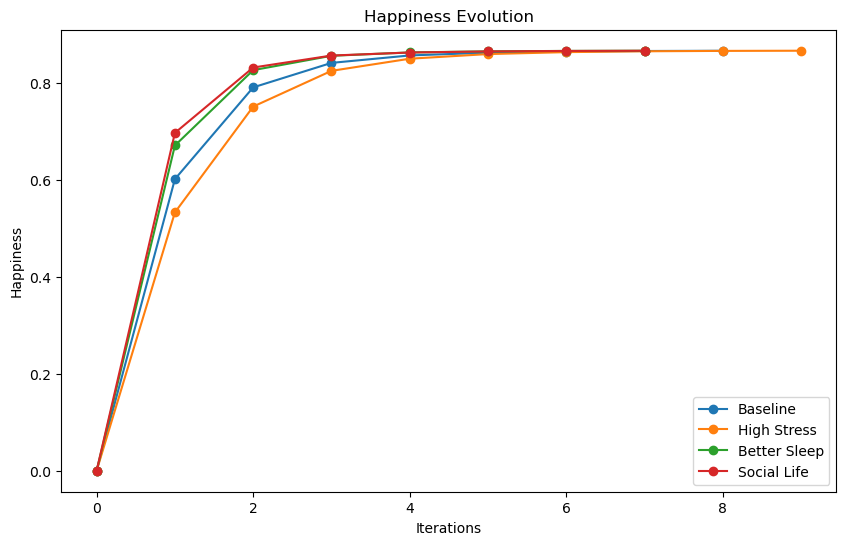

In [10]:
plt.figure(figsize=(10, 6))

plt.plot(res_sigmoid["Happiness"], label="Baseline", marker='o')
plt.plot(res_stress["Happiness"], label="High Stress", marker='o')
plt.plot(res_sleep["Happiness"], label="Better Sleep", marker='o')
plt.plot(res_social["Happiness"], label="Social Life", marker='o')

plt.legend()
plt.title("Happiness Evolution")
plt.xlabel("Iterations")
plt.ylabel("Happiness")

plt.show()

#### Scenario Analysis

Each scenario activates one concept while keeping others constant.

The results show how local changes propagate through the system.

Key observations:
- Stress reduces happiness
- Sleep improves happiness
- Social life has a strong positive effect

This confirms the interconnected nature of the system.

In [11]:
# Equilibrium Comparison
equilibrium_states = pd.DataFrame({
    "Baseline": res_sigmoid.iloc[-1],
    "High Stress": res_stress.iloc[-1],
    "Better Sleep": res_sleep.iloc[-1],
    "Social Life": res_social.iloc[-1]
})

display(equilibrium_states)

,Baseline,High Stress,Better Sleep,Social Life
Stress,0.388650,0.388512,0.388542,0.388595
Sleep,0.674808,0.674923,0.674899,0.674854
Social_Life,0.712007,0.712098,0.712078,0.712044
Productivity,0.735690,0.735797,0.735774,0.735733
Happiness,0.865631,0.865729,0.865707,0.865671


#### Equilibrium Comparison

The final state represents a stable equilibrium of the system under the given initial conditions.

Comparing these values allows us to evaluate how different scenarios affect the overall system outcome, especially the output concept Happiness.
The small differences between equilibrium values suggest that the system is relatively stable, meaning that individual changes have limited impact under the current weight configuration.

#### 9. Intervention

In [12]:
inter = FcmIntervention(FcmSimulator)

inter.initialize(
    initial_state=initial_state,
    weight_matrix=df,
    transfer="sigmoid",
    inference="mKosko",
    thresh=0.001,
    iterations=50,
    l=1
)

inter.add_intervention(
    "Reduce_Stress",
    type="continuous",
    impact={"Stress": -0.5},
    effectiveness=1
)

inter.test_intervention("Reduce_Stress", iterations=50)

res_intervention = inter.test_results["Reduce_Stress"][concepts]

The values converged in the 9 state (e <= 0.001)
The values converged in the 7 state (e <= 0.001)


/Users/allizha/miniconda3/envs/fcm38/lib/python3.8/site-packages/fcmpy/intervention/interventionConstructor.py:109: FutureWarning: The series.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  temp_vector = temp_vector.append(pd.Series({'intervention': effectiveness})).to_dict()


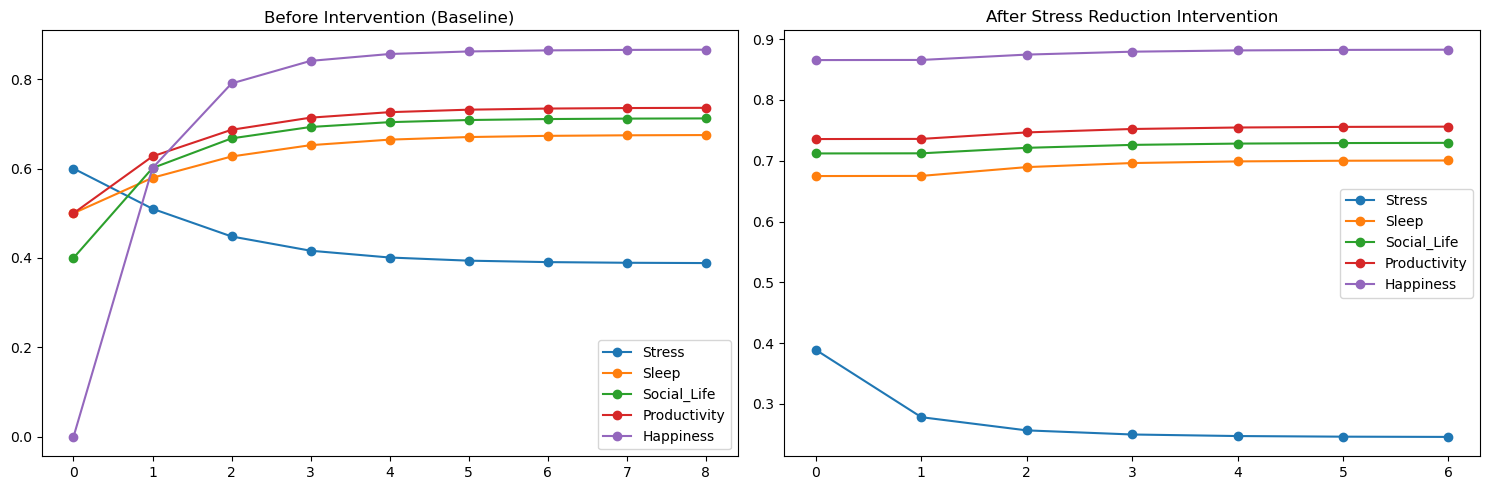

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Before intervention
res_sigmoid.plot(ax=axes[0], marker='o')
axes[0].set_title("Before Intervention (Baseline)")

# After intervention
res_intervention.plot(ax=axes[1], marker='o')
axes[1].set_title("After Stress Reduction Intervention")

plt.tight_layout()
plt.show()

This intervention modifies the activation level of Stress, indirectly influencing all connected concepts through the FCM structure.

#### Final Conclusion

Based on the Fuzzy Cognitive Map (FCM) simulation and structural analysis, the following conclusions can be drawn:

- **Impact of Stress:** Stress emerges as the dominant driving factor in the system. As indicated by the centrality analysis, it has the highest overall influence and consistently acts in a negative direction, reducing happiness and indirectly affecting other concepts.

- **Role of Positive Factors:** Sleep and Social_Life act as supportive and stabilizing components of the system. While they positively influence happiness, their effect is not strong enough to fully counterbalance high stress levels under the current model configuration.

- **System Behavior and Stability:** The simulations show that the system converges rapidly to a stable equilibrium. However, the similarity of equilibrium values across different scenarios suggests that the system is relatively insensitive to local changes, indicating limited dynamic variability.

- **Effect of Intervention:** The stress reduction intervention leads to an improvement in system outcomes, but the magnitude of change remains moderate. This highlights that altering a single concept has a distributed but constrained impact due to the interconnected structure of the FCM.